# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [217]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [218]:
filepath = "data/cleaned_aviation_data.csv"
dataset = pd.read_csv(filepath,encoding="latin-1", parse_dates=["Event.Date"])

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8652 entries, 0 to 8651
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Event.Date              8652 non-null   datetime64[ns]
 1   Injury.Severity         8652 non-null   object        
 2   Aircraft.damage         8251 non-null   object        
 3   Make                    8652 non-null   object        
 4   Model                   8652 non-null   object        
 5   Number.of.Engines       8652 non-null   float64       
 6   Engine.Type             7833 non-null   object        
 7   Purpose.of.flight       7474 non-null   object        
 8   Total.Fatal.Injuries    7559 non-null   float64       
 9   Total.Serious.Injuries  7534 non-null   float64       
 10  Total.Minor.Injuries    7646 non-null   float64       
 11  Total.Uninjured         8426 non-null   float64       
 12  Weather.Condition       8148 non-null   object  

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [219]:
dataset["Aircraft.Size"] = dataset["Total.People"].apply(
    lambda x: "Small" if x <= 20 else "Large"
)

dataset["Total.People"].describe()

count    8652.000000
mean       12.489020
std        42.419148
min         2.000000
25%         2.000000
50%         2.000000
75%         3.000000
max       588.000000
Name: Total.People, dtype: float64

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

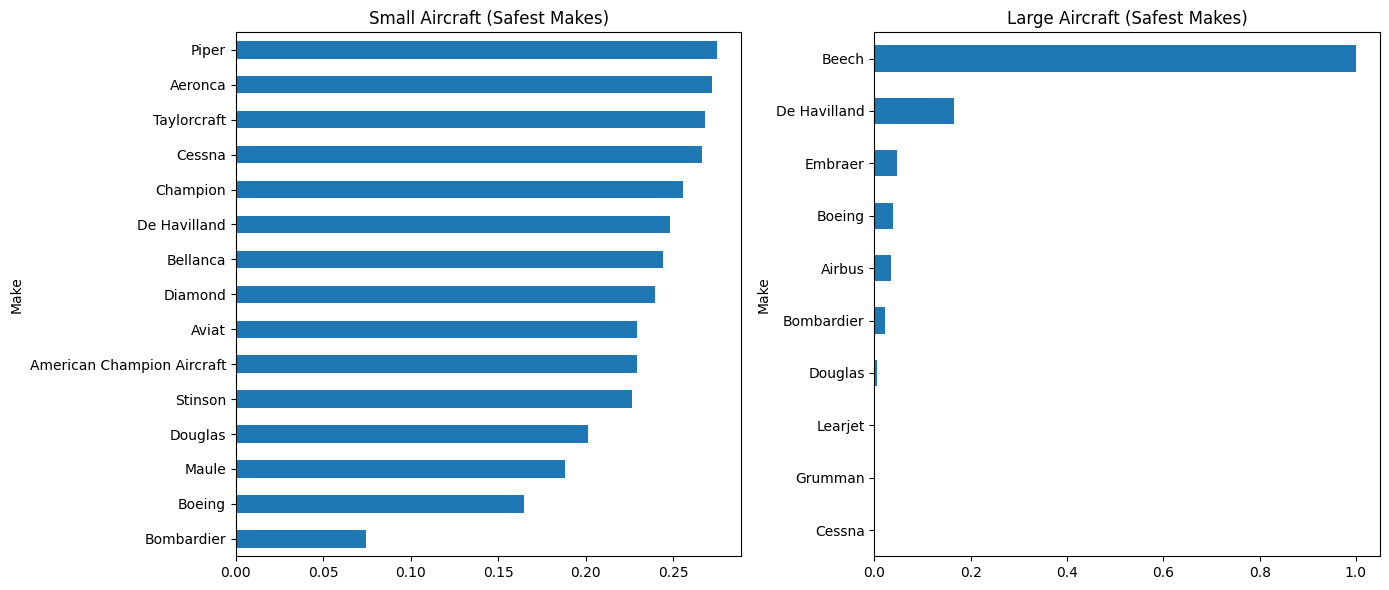

In [220]:
# Here I am grouping by the make, 
# calculating the mean, 
# sorting the values, 
# then getting the first 15

small_grouped = (
    dataset[dataset["Aircraft.Size"] == "Small"]
    .groupby("Make")["Critical.Injury.Rate"]
    .mean()
    .sort_values(ascending=True)
    .head(15)
)


large_grouped = (
    dataset[dataset["Aircraft.Size"] == "Large"]
    .groupby("Make")["Critical.Injury.Rate"]
    .mean()
    .sort_values(ascending=True)
    .head(15)
)


fig,axes = plt.subplots(1,2, figsize=(14,6))

small_grouped.plot(kind="barh", ax=axes[0], title="Small Aircraft (Safest Makes)")
large_grouped.plot(kind="barh", ax=axes[1], title="Large Aircraft (Safest Makes)")

plt.tight_layout()
plt.show()


**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

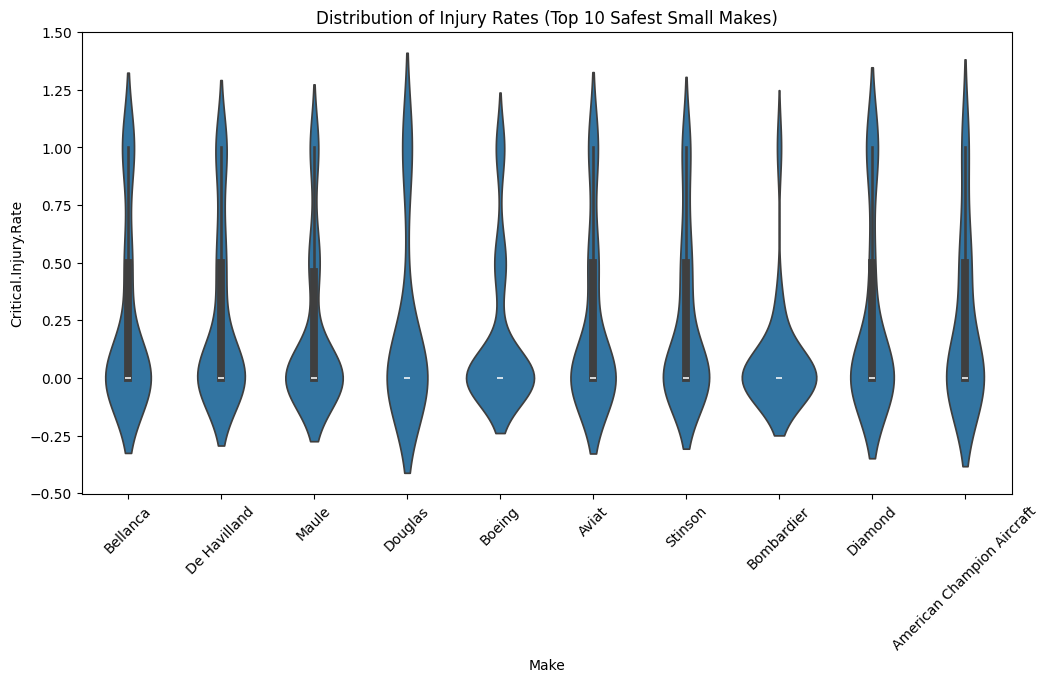

In [221]:
#Small grouped is itself a subset so I get the top 10 makes
subset_small_makes = small_grouped.head(10).index
#Then I get there full information from the original dataset
small_subset_data = dataset[
    (dataset["Aircraft.Size"] == "Small") &
    (dataset["Make"].isin(subset_small_makes))
]

plt.figure(figsize=(12,6))
sns.violinplot(
    data=small_subset_data,
    x="Make",
    y="Critical.Injury.Rate"
)

plt.title("Distribution of Injury Rates (Top 10 Safest Small Makes)")
plt.xticks(rotation=45)
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

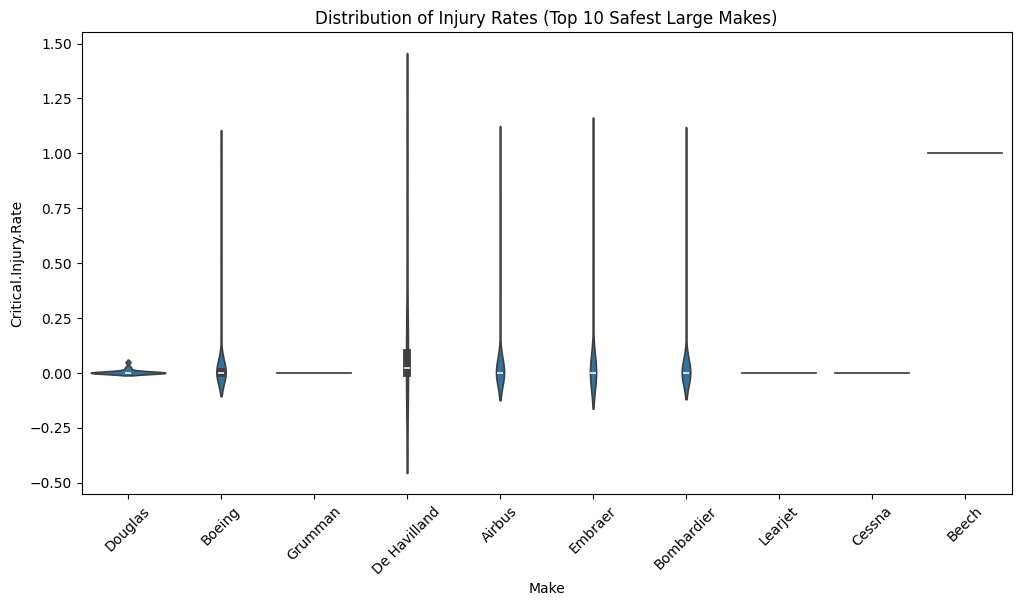

In [222]:
#Large grouped is itself a subset so I get the top 10 makes
subset_large_makes = large_grouped.head(10).index
#Then I get there full information from the original dataset
large_subset_data = dataset[
    (dataset["Aircraft.Size"] == "Large") &
    (dataset["Make"].isin(subset_large_makes))
]

plt.figure(figsize=(12,6))
sns.violinplot(
    data=large_subset_data,
    x="Make",
    y="Critical.Injury.Rate"
)

plt.title("Distribution of Injury Rates (Top 10 Safest Large Makes)")
plt.xticks(rotation=45)
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [223]:
small_destroyed = (
    dataset[dataset["Aircraft.Size"] == "Small"]
    .groupby("Make")["Plane.Destroyed"]
    .mean()
    .sort_values()
    .head(15)
)

large_destroyed = (
    dataset[dataset["Aircraft.Size"] == "Large"]
    .groupby("Make")["Plane.Destroyed"]
    .mean()
    .sort_values()
    .head(15)
)


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.